# Introduction

Understanding why users stop using Spotify is essential for improving user retention and increasing revenue. This project analyzes user listening behavior, engagement patterns, and subscription types to identify churn indicators and predict users at risk of leaving.

# import Library

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Read data

In [62]:
df = pd.read_csv("/kaggle/input/datasets/nabihazahid/spotify-dataset-for-churn-analysis/spotify_churn_dataset.csv")
df

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...
7995,7996,Other,44,DE,Student,237,36,0.30,Mobile,0,1,1
7996,7997,Male,34,AU,Premium,61,64,0.59,Mobile,0,1,0
7997,7998,Female,17,US,Free,81,62,0.33,Desktop,5,0,0
7998,7999,Female,34,IN,Student,245,94,0.27,Desktop,0,1,0


# Data Preprocessing

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                8000 non-null   int64  
 1   gender                 8000 non-null   object 
 2   age                    8000 non-null   int64  
 3   country                8000 non-null   object 
 4   subscription_type      8000 non-null   object 
 5   listening_time         8000 non-null   int64  
 6   songs_played_per_day   8000 non-null   int64  
 7   skip_rate              8000 non-null   float64
 8   device_type            8000 non-null   object 
 9   ads_listened_per_week  8000 non-null   int64  
 10  offline_listening      8000 non-null   int64  
 11  is_churned             8000 non-null   int64  
dtypes: float64(1), int64(7), object(4)
memory usage: 750.1+ KB


In [64]:
df.head()

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
0,1,Female,54,CA,Free,26,23,0.20,Desktop,31,0,1
1,2,Other,33,DE,Family,141,62,0.34,Web,0,1,0
2,3,Male,38,AU,Premium,199,38,0.04,Mobile,0,1,1
3,4,Female,22,CA,Student,36,2,0.31,Mobile,0,1,0
4,5,Other,29,US,Family,250,57,0.36,Mobile,0,1,1


In [65]:
df.shape

(8000, 12)

In [66]:
df.sample(10)

,user_id,gender,age,country,subscription_type,listening_time,songs_played_per_day,skip_rate,device_type,ads_listened_per_week,offline_listening,is_churned
7646,7647,Other,52,IN,Premium,58,11,0.55,Web,0,1,0
2005,2006,Other,40,PK,Student,92,24,0.04,Mobile,0,1,0
1821,1822,Female,52,US,Family,119,2,0.21,Mobile,0,1,0
781,782,Male,32,US,Premium,71,53,0.54,Web,0,1,0
5052,5053,Female,37,CA,Free,100,93,0.33,Desktop,27,0,0
6047,6048,Female,52,PK,Student,297,63,0.10,Mobile,0,1,0
6929,6930,Male,40,CA,Free,26,81,0.45,Desktop,7,0,1
1951,1952,Female,21,IN,Free,286,35,0.55,Desktop,13,0,0
4442,4443,Female,31,US,Premium,23,76,0.55,Desktop,0,1,0
3768,3769,Female,40,PK,Student,191,70,0.29,Web,0,1,0


In [67]:
df.describe()

,user_id,age,listening_time,songs_played_per_day,skip_rate,ads_listened_per_week,offline_listening,is_churned
count,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,4000.50000,37.662125,154.068250,50.127250,0.300127,6.943875,0.747750,0.258875
std,2309.54541,12.740359,84.015596,28.449762,0.173594,13.617953,0.434331,0.438044
min,1.00000,16.000000,10.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,2000.75000,26.000000,81.000000,25.000000,0.150000,0.000000,0.000000,0.000000
50%,4000.50000,38.000000,154.000000,50.000000,0.300000,0.000000,1.000000,0.000000
75%,6000.25000,49.000000,227.000000,75.000000,0.450000,5.000000,1.000000,1.000000
max,8000.00000,59.000000,299.000000,99.000000,0.600000,49.000000,1.000000,1.000000


In [68]:
df.describe(include="O")

,gender,country,subscription_type,device_type
count,8000,8000,8000,8000
unique,3,8,4,3
top,Male,AU,Premium,Desktop
freq,2691,1034,2115,2778


In [69]:
df.duplicated().sum()

np.int64(0)

In [70]:
df.isnull().sum()

user_id                  0
gender                   0
age                      0
country                  0
subscription_type        0
listening_time           0
songs_played_per_day     0
skip_rate                0
device_type              0
ads_listened_per_week    0
offline_listening        0
is_churned               0
dtype: int64

# EDA

In [71]:
#rata listening_time per gender
avg_listening_time_gender = df.groupby('gender')['listening_time'].mean()


print("Average listening time per gender:")
print(avg_listening_time_gender)

Average listening time per gender:
gender
Female    153.860850
Male      153.623188
Other     154.728302
Name: listening_time, dtype: float64


In [72]:
avg_listening_time_country=df.groupby('country')['listening_time'].mean()

print('Average listening time for each country:')
print(avg_listening_time_country)

Average listening time for each country:
country
AU    151.930368
CA    152.407757
DE    157.229557
FR    155.319515
IN    154.695351
PK    152.779780
UK    153.145963
US    154.933140
Name: listening_time, dtype: float64


## Correlation


In [73]:
#Correlation between age and listening time
correlation_age_listening = df['age'].corr(df['listening_time'])
print(f"\nCorrelation between age and listening time: {correlation_age_listening}")


Correlation between age and listening time: -0.012975472135472572


In [74]:
#Correlation between age and skip rate
correlation_age_skiprate = df['age'].corr(df['skip_rate'])
print(f"\nCorrelation between age and skip rate: {correlation_age_skiprate}")


Correlation between age and skip rate: -0.01955713786409894


In [75]:
# Create a copy of the DataFrame to avoid changing the original data
df_corr = df.copy()

# Convert the 'gender' column to numeric codes
df_corr['gender_numeric'] = df_corr['gender'].astype('category').cat.codes

# Calculate the correlation between gender_numeric and skip_rate
correlation_gender_skiprate = df_corr['gender_numeric'].corr(df_corr['skip_rate'])

# Display the result
print(f"Correlation between gender and skip rate: {correlation_gender_skiprate}")

# You can also see the numeric codes assigned to each gender
print("\nNumeric code for gender:")
print(df_corr[['gender', 'gender_numeric']].drop_duplicates())

Correlation between gender and skip rate: 0.004332503417976405

Numeric code for gender:
   gender  gender_numeric
0  Female               0
1   Other               2
2    Male               1


Final Summary of All Analysis Results Gender vs. Listening Time: The difference in average listening time between genders is very small and negligible.

Country vs. Listening Time: There is a more significant difference between countries, with Germany (157 minutes) having the highest and Australia (152 minutes) having the lowest.

Age & Listening Time Correlation (-0.013): This correlation is very weak and approaches zero. This means there is no meaningful linear relationship between users' age and the amount of time they listen to music.

Age & Skip Rate Correlation (-0.019): As before, this correlation is very weak. Age is not a factor in determining whether someone will frequently skip songs or not.

Gender & Skip Rate Correlation (0.004): This correlation is practically zero. Gender has no relationship whatsoever with song skipping behavior.

In [76]:
# 1. Determine the 'active users' threshold
high_play_count_threshold = df['songs_played_per_day'].quantile(0.75)

# 2. Filter target users
targeted_users = df[
(df['songs_played_per_day'] > high_play_count_threshold) &
(df['offline_listening'] == 0)
]

print(f"The threshold for high 'songs_played_per_day' is: {high_play_count_threshold: .2f} songs/day")
print(f"\nFound {len(targeted_users)} users who are highly active but not using the feature offline.")

# 3. Analyze the distribution of 'device_type'
device_distribution = targeted_users['device_type'].value_counts()
print("\nDevice Type Distribution for Target Users:")
print(device_distribution)

# 4. (CRUSTIC ADDITIONAL) Analyze the distribution of 'subscription_type'
subscription_distribution = targeted_users['subscription_type'].value_counts()
print("\nSubscription Type Distribution for Target Users:")
print(subscription_distribution)

The threshold for high 'songs_played_per_day' is:  75.00 songs/day

Found 482 users who are highly active but not using the feature offline.

Device Type Distribution for Target Users:
device_type
Mobile     177
Desktop    157
Web        148
Name: count, dtype: int64

Subscription Type Distribution for Target Users:
subscription_type
Free    482
Name: count, dtype: int64



Based on the analyzed data, the main conclusion is that user profiles such as age, gender, or even subscription type are not the determining factors in how long someone listens to music. The most valuable insights come from specific user behaviors. It was discovered that there is a group of highly active and loyal free users who have not yet taken advantage of premium features like offline listening.

Therefore, the most effective development strategy is not to target broad user categories, but rather to focus on monetizing this existing loyal segment. This involves creating highly targeted campaigns that introduce the benefits of paid features that are relevant to their listening habits, thus encouraging them to convert to subscribers.

## User overview

In [77]:
#What percentage of users are male vs. female?
df.groupby('gender').size() / len(df) * 100

gender
Female    33.2375
Male      33.6375
Other     33.1250
dtype: float64

In [78]:
# What is the average age of users? Who is the youngest and oldest?
avg_age = df['age'].mean() # Average
youngest_age = df['age'].min() # Youngest
oldest_age = df['age'].max() # Oldest
print('Avg Age:', avg_age)
print('Youngest Age:', youngest_age)
print('Oldest Age', oldest_age)

Avg Age: 37.662125
Youngest Age: 16
Oldest Age 59


In [79]:
# Which countries are the users from?
df.groupby('country').size()

country
AU    1034
CA     954
DE    1015
FR     989
IN    1011
PK     999
UK     966
US    1032
dtype: int64

### Subscription & Device Data


In [80]:
# Number of Users per Subscription Type
subscription_count = df['subscription_type'].value_counts()

# Percentage of Users per Subscription Type
subscription_percentage = df['subscription_type'].value_counts(normalize=True) * 100

# Most Popular Subscription Type
most_popular = df['subscription_type'].value_counts().idxmax()

print("Number of Users per Subscription Type:")
print(subscription_count, "\n")

print("Percentage of Users per Subscription Type (%):")
print(subscription_percentage, "\n")

print(f"Most Popular Subscription Type: {most_popular}")

Number of Users per Subscription Type:
subscription_type
Premium    2115
Free       2018
Student    1959
Family     1908
Name: count, dtype: int64 

Percentage of Users per Subscription Type (%):
subscription_type
Premium    26.4375
Free       25.2250
Student    24.4875
Family     23.8500
Name: proportion, dtype: float64 

Most Popular Subscription Type: Premium


Insight:
Across all subscription types—Family, Free, Premium, and Student—the number of users is fairly balanced across genders, with no major gaps. Male users tend to have slightly higher counts in most categories, particularly in the Premium and Family plans, while Female users show strong representation in the Free and Student plans. “Other” gender users also follow a similar pattern with consistently steady counts. Overall, subscription preferences appear broadly similar across genders, with only small variations.

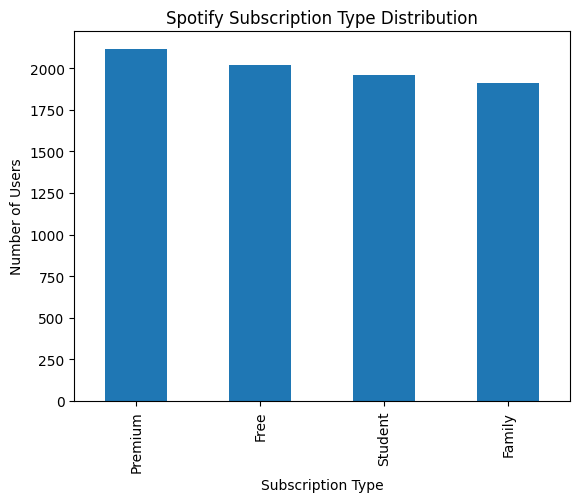

In [81]:
df['subscription_type'].value_counts().plot(kind='bar')
plt.xlabel("Subscription Type")
plt.ylabel("Number of Users")
plt.title("Spotify Subscription Type Distribution")
plt.show()

In [82]:
# Device_Type Do users use mobile or desktop more?

# 1. Number of users per device
device_count = df['device_type'].value_counts()
print("Number of users per device:")
print(device_count)
print()

# 2. Percentage of users
device_percentage = df['device_type'].value_counts(normalize=True) * 100
print("Percentage of users per device (%):")
print(device_percentage)
print()

Number of users per device:
device_type
Desktop    2778
Web        2623
Mobile     2599
Name: count, dtype: int64

Percentage of users per device (%):
device_type
Desktop    34.7250
Web        32.7875
Mobile     32.4875
Name: proportion, dtype: float64



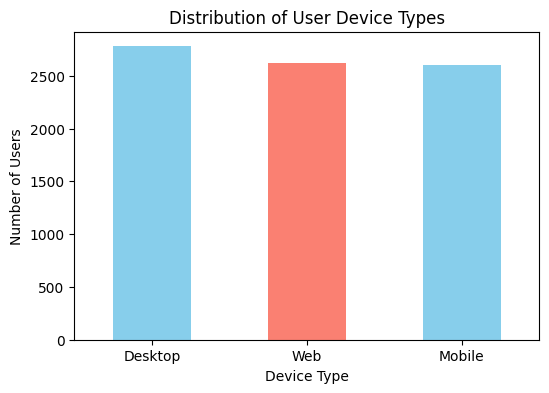

In [83]:
# 3. Bar chart visualization
plt.figure(figsize=(6,4))
device_count.plot(kind='bar', color=['skyblue','salmon'])
plt.title("Distribution of User Device Types")
plt.xlabel("Device Type")
plt.ylabel("Number of Users")
plt.xticks(rotation=0)
plt.show()

Insight:
Desktop users show the highest overall usage (2,778), slightly exceeding Web (2,623) and Mobile (2,599). Although all three device types have similar usage levels, Desktop leads by a small margin, suggesting users may engage more deeply or for longer sessions when using desktop devices compared to mobile or web platforms

In [84]:
# Calculate the Average Behavioral Data

average = {
"listening_time_per_day(minutes)": df["songs_played_per_day"].mean(),
"songs_played_per_day": df["songs_played_per_day"].mean(),
"skip_rate": df["skip_rate"].mean(),
"ads_listened_per_week": df["ads_listened_per_week"].mean(),
"offline_listening_time(minutes)": df["offline_listening"].mean()
}

average_behavior_data = pd.DataFrame.from_dict(average, orient='index', columns=['Average'])
print(average_behavior_data)

                                   Average
listening_time_per_day(minutes)  50.127250
songs_played_per_day             50.127250
skip_rate                         0.300127
ads_listened_per_week             6.943875
offline_listening_time(minutes)   0.747750


# Comparative Analysis to Find Churn Patterns

In [85]:
# Calculate the average listening time per day (minutes) for each churn status
average_per_churn = df.groupby("is_churned")["songs_played_per_day"].mean()

print(average_per_churn)

is_churned
0    49.970653
1    50.575567
Name: songs_played_per_day, dtype: float64


In [86]:
# Calculate the average skip percentage for each churn status
rata_skip_per_churn = df.groupby("is_churned")["skip_rate"].mean()

print(rata_skip_per_churn)

is_churned
0    0.298474
1    0.304862
Name: skip_rate, dtype: float64


In [87]:
# 1. Filter the data for Premium, Student, and Family subscription types only.
filtered_df = df[df["subscription_type"].isin(["Premium", "Student", "Family"])]

# 2. Group by churn_status and calculate the average offline listening time (minutes).
rata_offline_per_churn= (
filtered_df.groupby("is_churned")["offline_listening"].mean()
)

print(rata_offline_per_churn)

is_churned
0    1.0
1    1.0
Name: offline_listening, dtype: float64


In [88]:
# Calculate the number of churns (churn_status=1) and the total number of users per subscription_type
churn_rate = (
df.groupby("subscription_type")["is_churned"]
.apply(lambda x: (x.sum() / x.count()) * 100)
)

# For better organization, create a DataFrame
churn_rate_df = churn_rate.reset_index()
churn_rate_df.columns = ["Subscription Type", "Churn Percentage (%)"]

print(churn_rate_df)

  Subscription Type  Churn Percentage (%)
0            Family             27.515723
1              Free             24.925669
2           Premium             25.059102
3           Student             26.186830


In [89]:
# 1. Filter data for Free users only
free_users = df[df["subscription_type"] == "Free"]

# 2. Group by churn_status and calculate the average number of ads listened to per week
average_free_ads = (
free_users.groupby("is_churned")["ads_listened_per_week"].mean()
)

print(average_free_ads)

is_churned
0    27.246865
1    28.373757
Name: ads_listened_per_week, dtype: float64


# Data Visualization

In [90]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(numerical_cols)

Index(['user_id', 'age', 'listening_time', 'songs_played_per_day', 'skip_rate',
       'ads_listened_per_week', 'offline_listening', 'is_churned'],
      dtype='object')


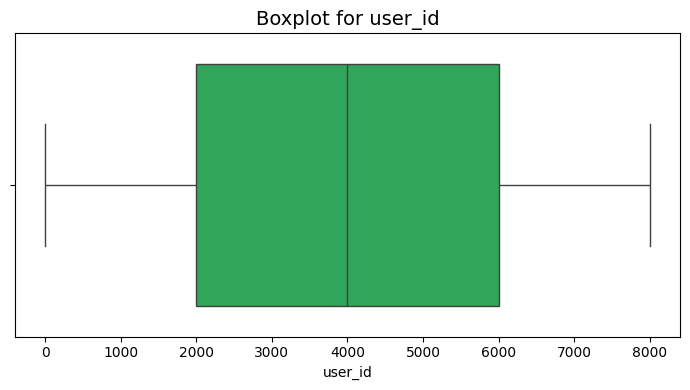

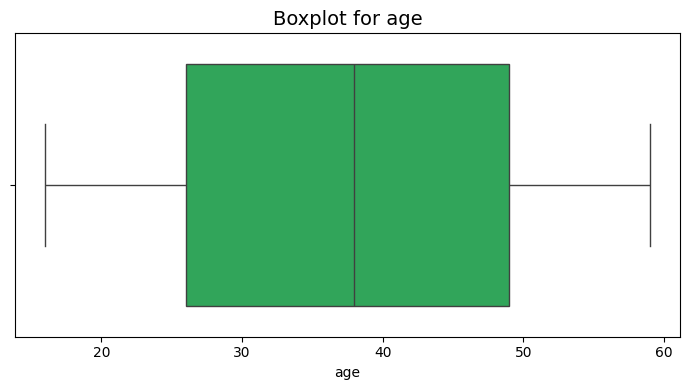

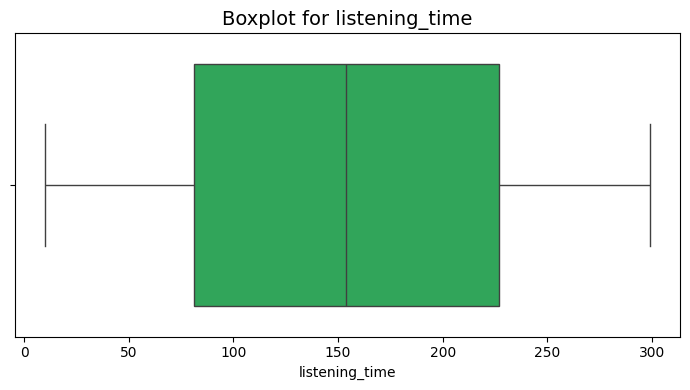

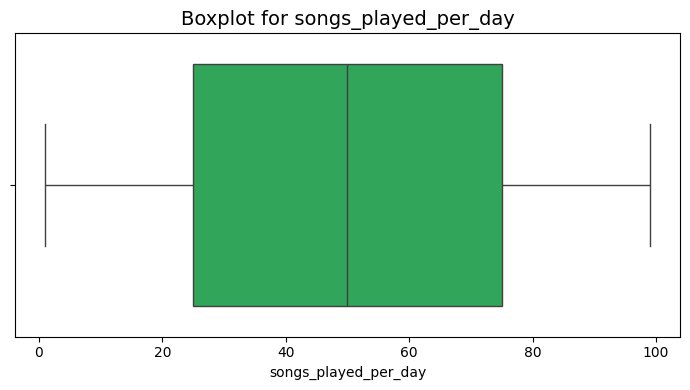

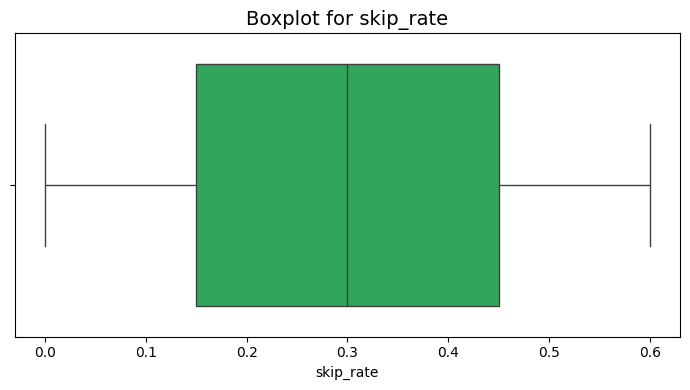

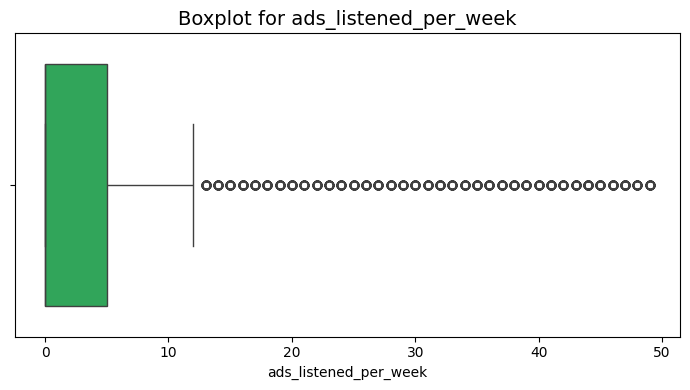

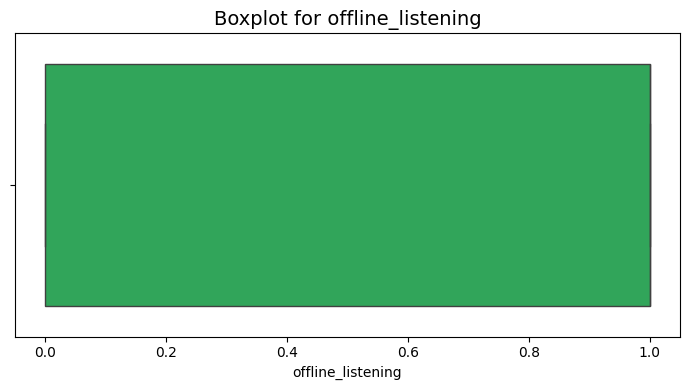

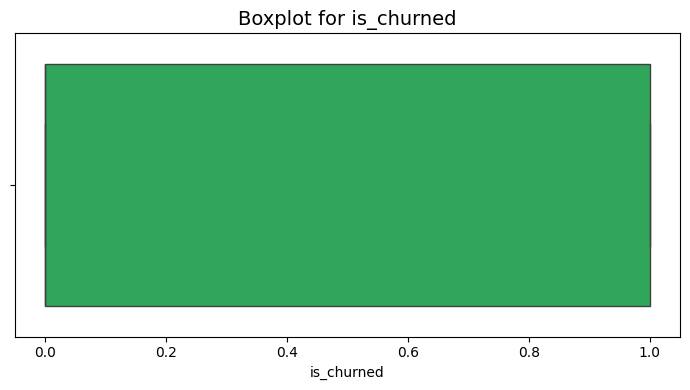

In [91]:
spotify_green = '#1DB954'
for col in numerical_cols:
    plt.figure(figsize=(7, 4))
    sns.boxplot(x=df[col], color=spotify_green)
    plt.title(f'Boxplot for {col}', fontsize=14)
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

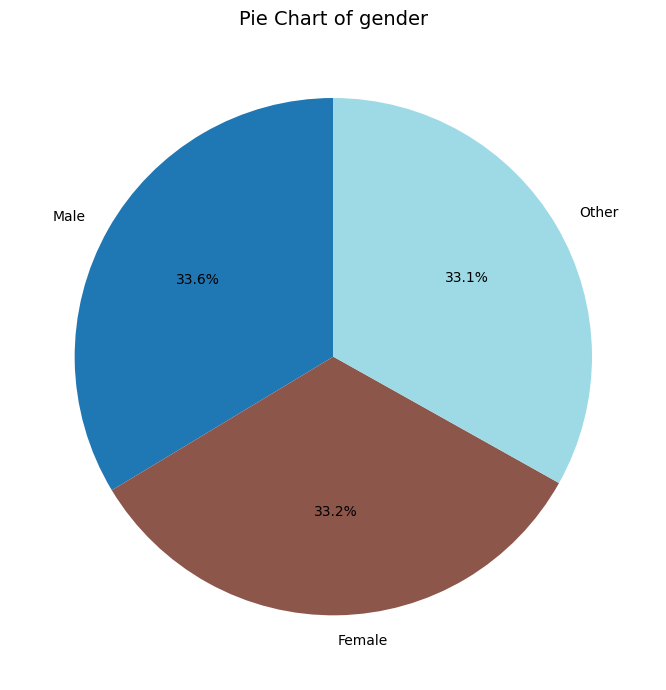

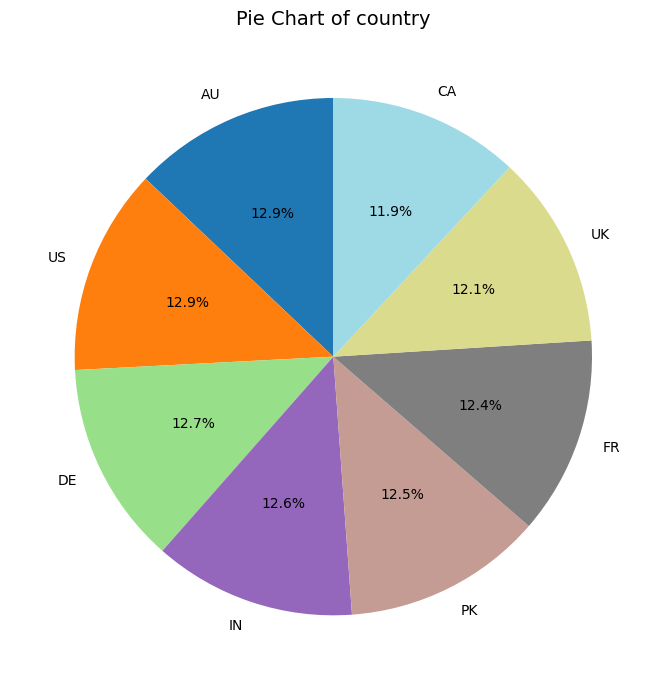

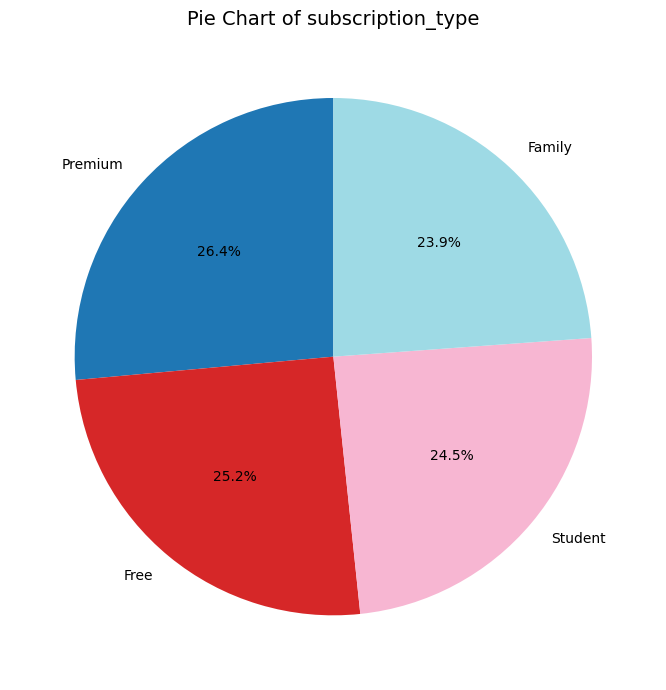

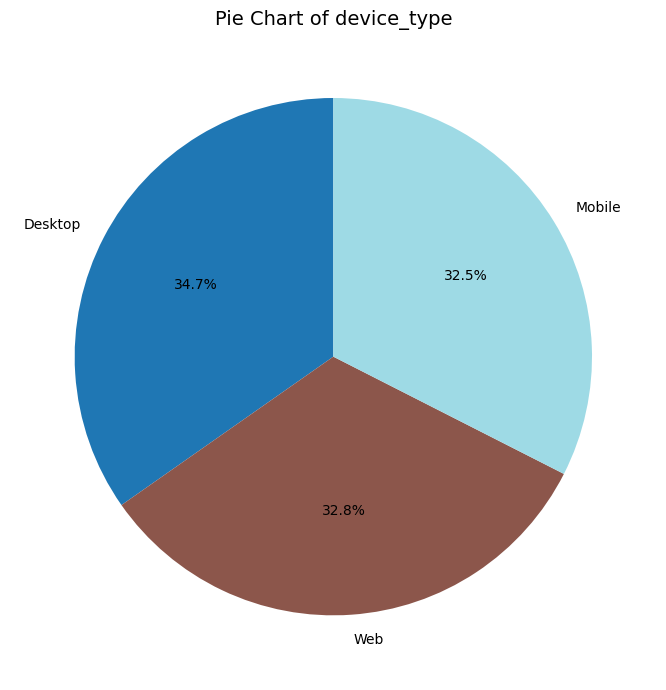

In [92]:
categorical_cols = df.select_dtypes(include=['object', 'category']).columns
for col in categorical_cols:
    plt.figure(figsize=(7, 7))
    df[col].value_counts().plot.pie(
        autopct='%1.1f%%',
        startangle=90,
        cmap='tab20'
    )
    plt.title(f'Pie Chart of {col}', fontsize=14)
    plt.ylabel('')
    plt.tight_layout()
    plt.show()

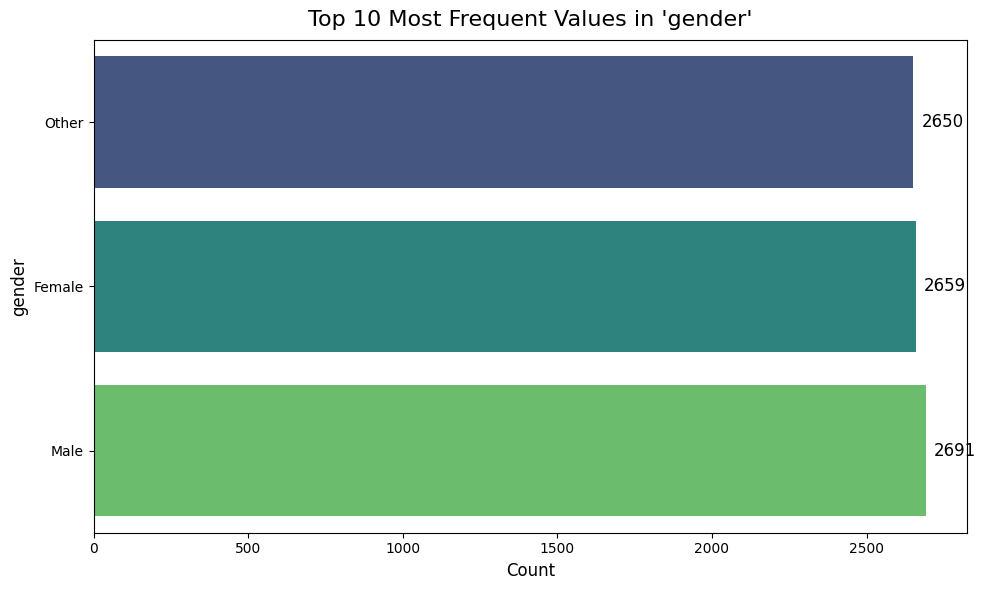

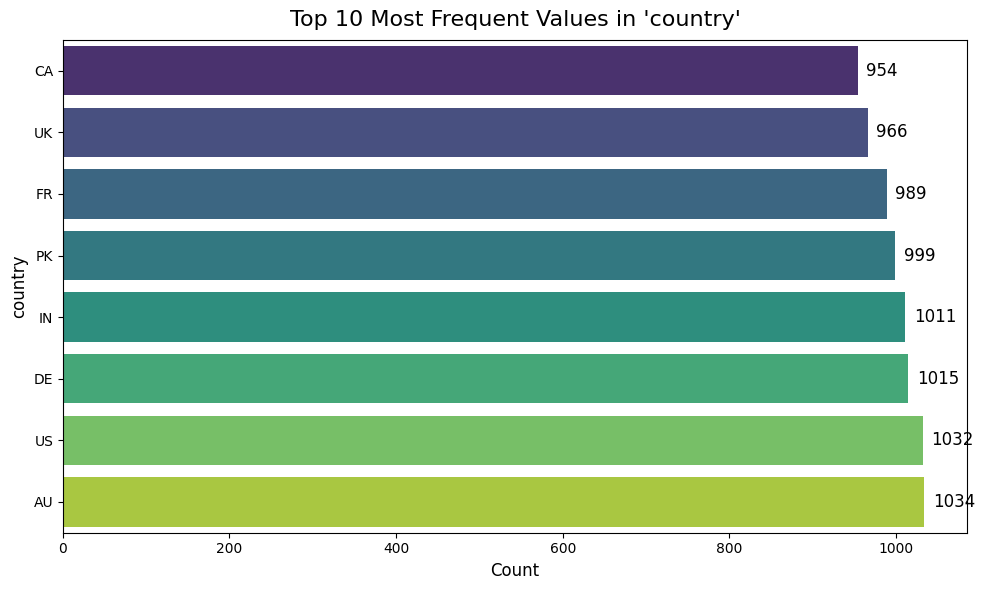

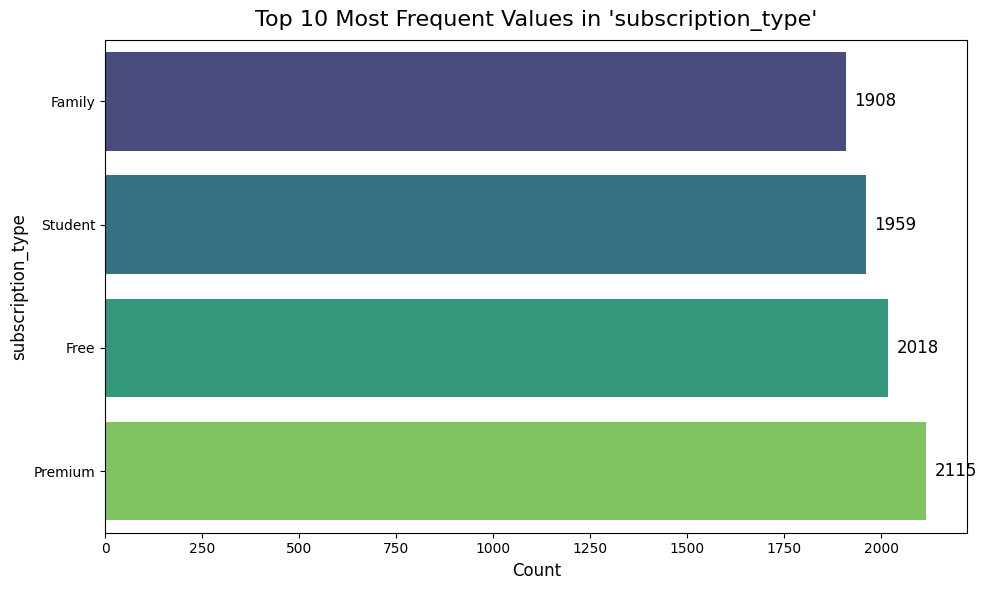

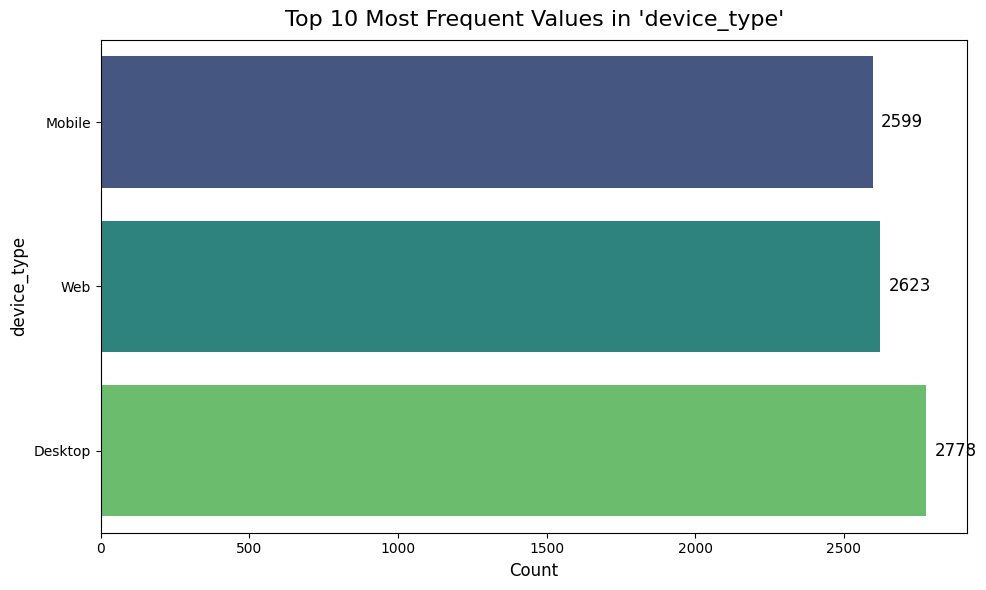

In [93]:
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    top_values = df[col].value_counts().nlargest(10).sort_values()
    sns.barplot(
        x=top_values.values,
        y=top_values.index,
        palette=sns.color_palette("viridis", len(top_values))
    )

    plt.title(f"Top 10 Most Frequent Values in '{col}'", fontsize=16, pad=10)
    # Labels
    plt.xlabel("Count", fontsize=12)
    plt.ylabel(col, fontsize=12)
    #  value labels
    for i, v in enumerate(top_values.values):
        plt.text(v + max(top_values.values)*0.01, i, str(v), fontsize=12, va='center')

    plt.tight_layout()
    plt.show()

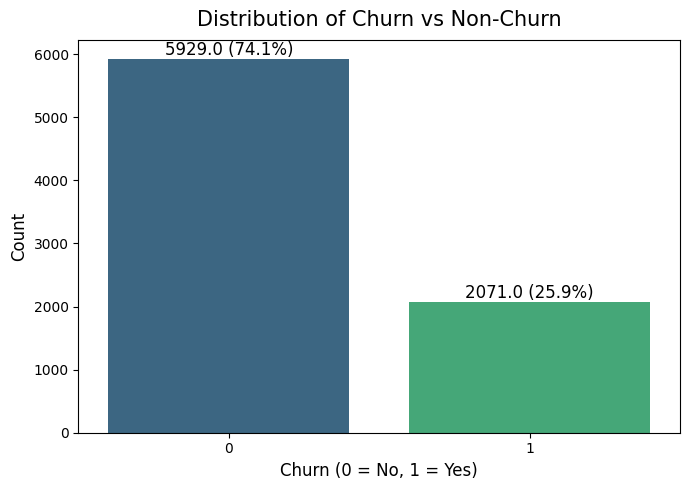

In [94]:
plt.figure(figsize=(7,5))
ax = sns.countplot(
    x="is_churned",
    data=df,
    palette=sns.color_palette("viridis", 2)
)
plt.title("Distribution of Churn vs Non-Churn", fontsize=15, pad=10)
plt.xlabel("Churn (0 = No, 1 = Yes)", fontsize=12)
plt.ylabel("Count", fontsize=12)
total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.text(
        p.get_x() + p.get_width()/2,
        count,
        f"{count} ({percentage:.1f}%)",
        ha="center", va="bottom", fontsize=12
    )
plt.tight_layout()
plt.show()
       

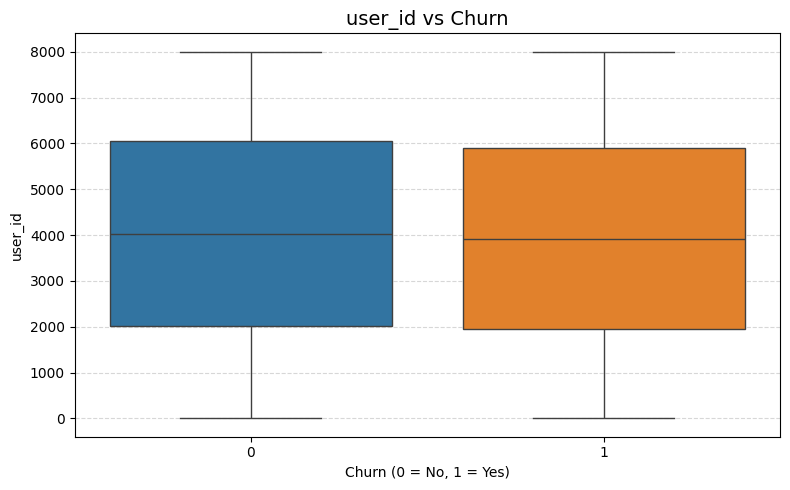

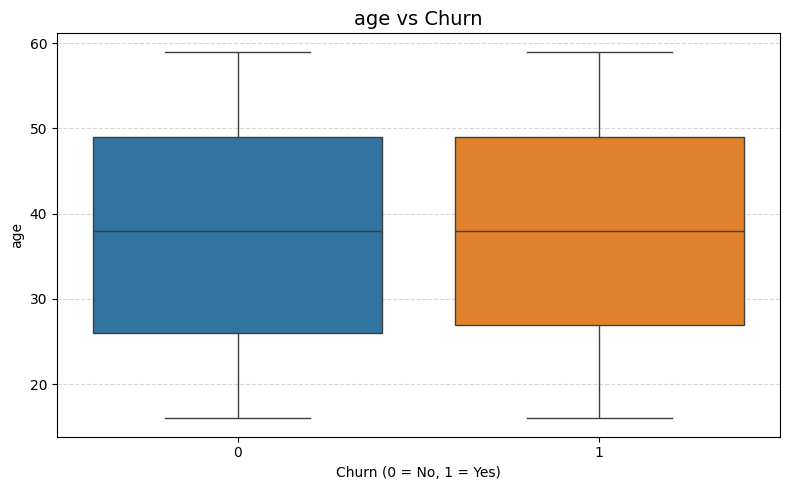

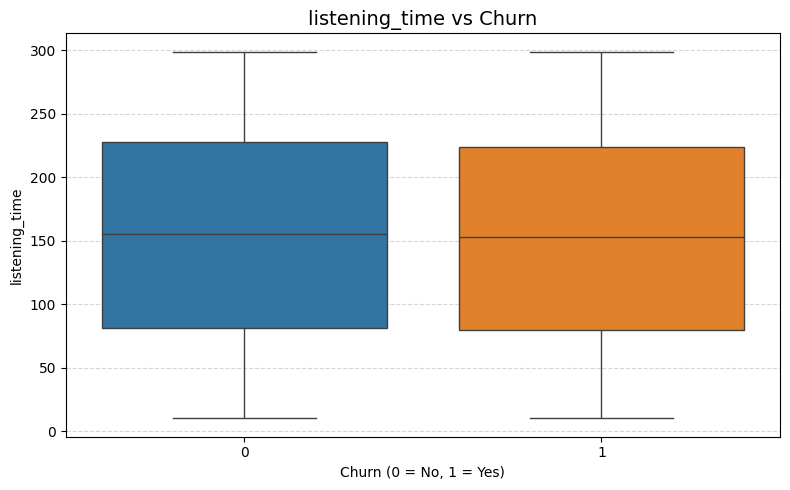

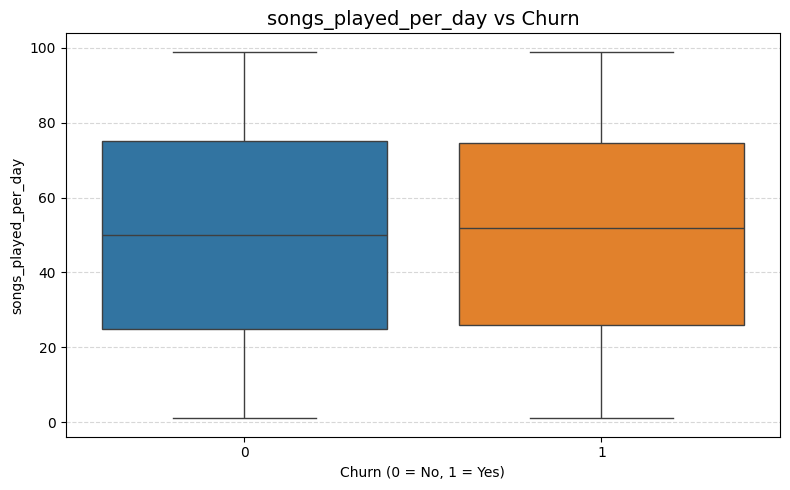

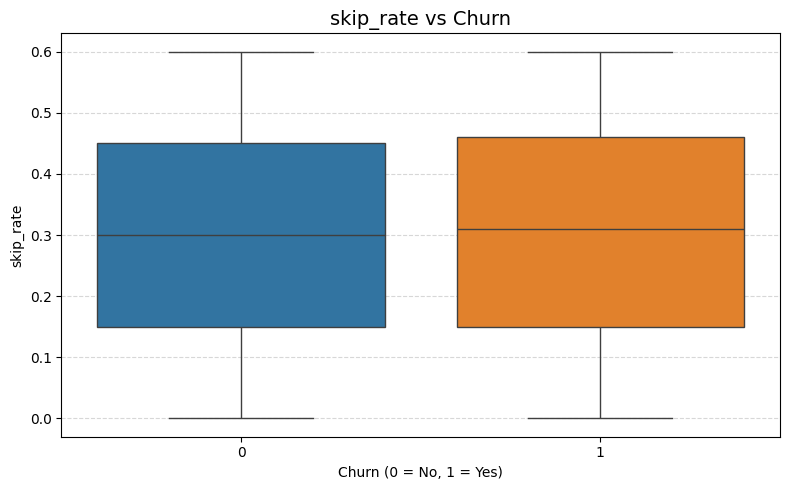

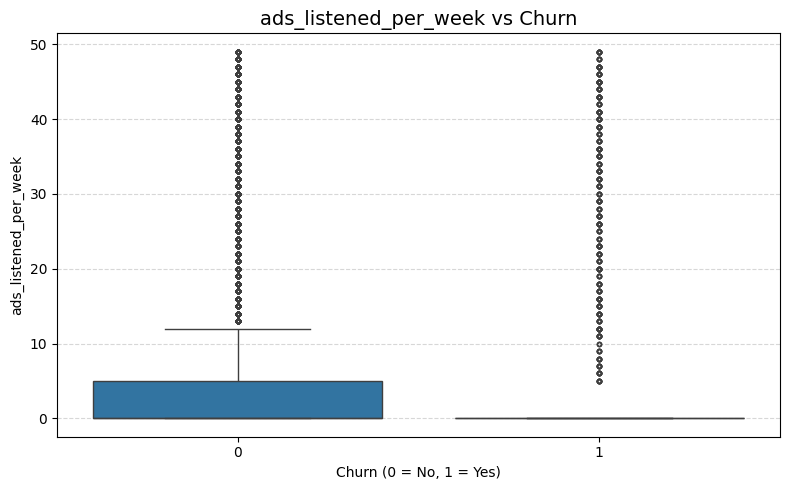

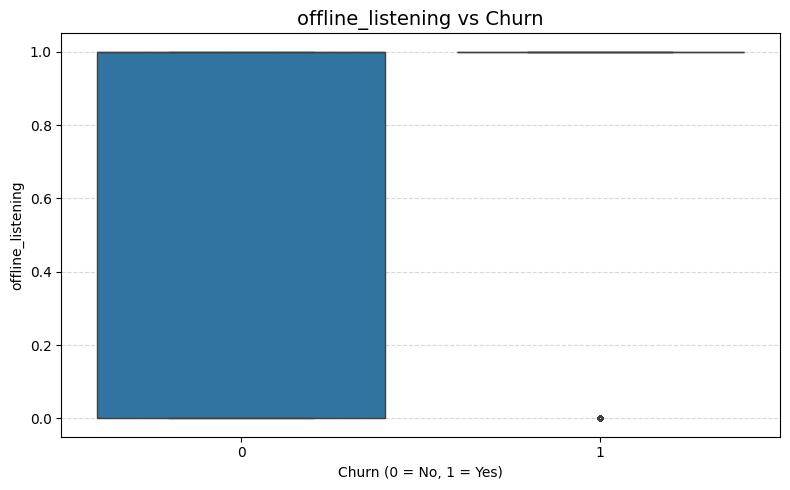

In [95]:
num_features = df.select_dtypes(include=['int64','float64']).columns.drop("is_churned")
for col in num_features:
    plt.figure(figsize=(8,5))
    sns.boxplot(
        x="is_churned", 
        y=col, 
        data=df, 
        palette=["#1f77b4", "#ff7f0e"],
        fliersize=3 
    )
    plt.title(f"{col} vs Churn", fontsize=14)
    plt.xlabel("Churn (0 = No, 1 = Yes)")
    plt.ylabel(col)
    plt.grid(axis='y', linestyle='--', alpha=0.5)  
    plt.tight_layout()
    plt.show()

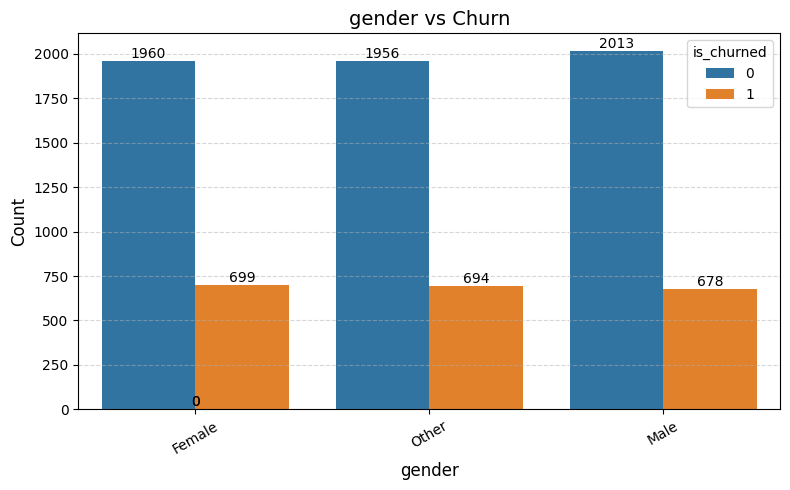

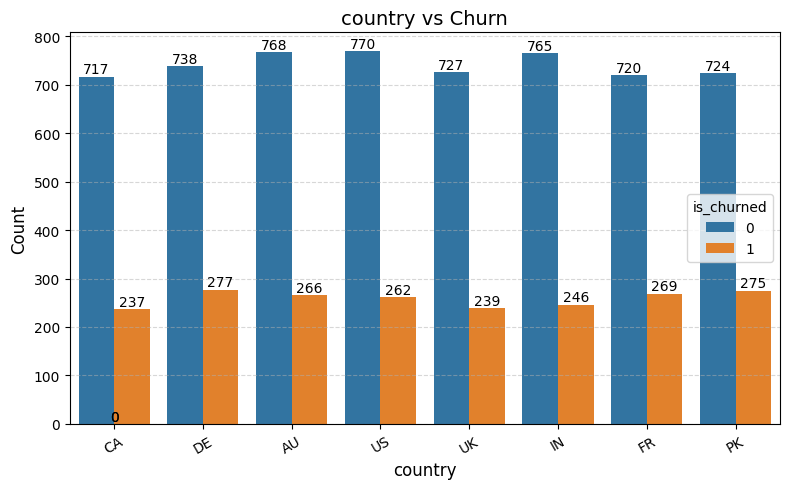

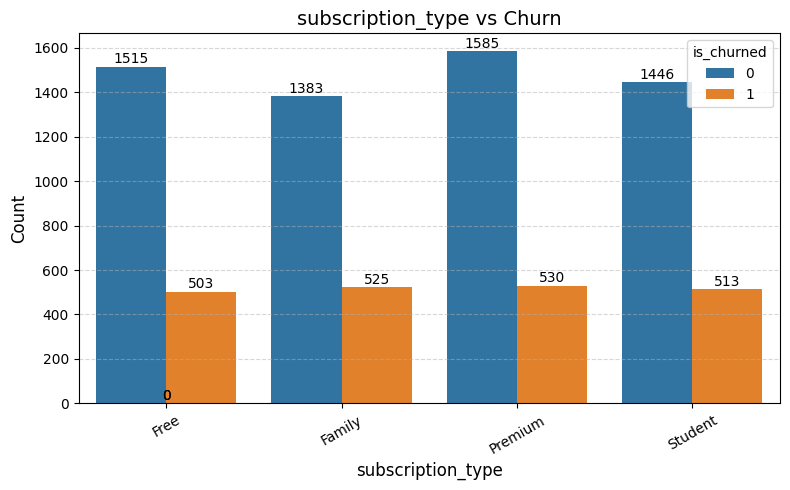

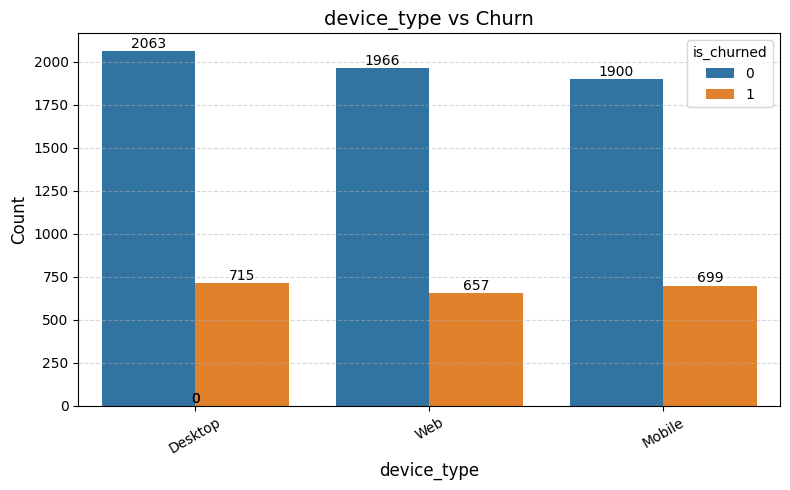

In [96]:
cat_features = df.select_dtypes(include=['object']).columns
for col in cat_features:
    plt.figure(figsize=(8,5))
    sns.countplot(
        x=col, 
        hue="is_churned", 
        data=df, 
        palette=["#1f77b4", "#ff7f0e"]
    )
    plt.title(f"{col} vs Churn", fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.xticks(rotation=30)
    plt.grid(axis='y', linestyle='--', alpha=0.5)  

    ax = plt.gca()
    for p in ax.patches:
        height = p.get_height()
        ax.text(
            p.get_x() + p.get_width()/2, 
            height + 0.5, 
            int(height), 
            ha='center', 
            va='bottom', 
            fontsize=10
        )
    plt.tight_layout()
    plt.show()

# Conclusion:¶



This analysis examined user listening behavior, subscription types, and engagement patterns to identify factors influencing churn. The results show that user engagement is the strongest driver of retention.

Users with higher listening time and lower skip rates are less likely to churn, while users with low activity and high skip rates are more likely to leave. Subscription type and device usage showed minimal impact on churn compared to engagement metrics.

💡 Key Takeaway
Improving music recommendations, reducing skip rates, and targeting low-engagement users can help Spotify reduce churn and improve user retention.